In [ ]:
!pip install rdkit -qqq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 51.5 MB/s eta 0:00:00


In [ ]:
!pip install openbabel-wheel openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 51.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import os
import re
from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole
from IPython.display import display
import math
import subprocess
import tempfile
import csv
import openpyxl

In [ ]:
df = pd.read_excel('/content/Final_Master.xlsx')

In [ ]:
df.shape

(659, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 659 entries, 0 to 658
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   catalyst        659 non-null    object 
 1   reaction        659 non-null    object 
 2   direction       659 non-null    object 
 3   bond_type       659 non-null    object 
 4   delta_g_rxn     659 non-null    float64
 5   delta_g         558 non-null    float64
 6   IP              659 non-null    float64
 7   Allen_EN        659 non-null    float64
 8   Pauling_EN      659 non-null    float64
 9   work_function   659 non-null    float64
 10  d_band_center   659 non-null    float64
 11  d_bandwidth     659 non-null    float64
 12  d_band_filling  659 non-null    float64
 13  cohesive        659 non-null    float64
 14  lat_cons        659 non-null    float64
dtypes: float64(11), object(4)
memory usage: 77.4+ KB


**For null values and removal of faulty data**


* **As data is experimantal and from DFT, neither can we augment the data nor fill the null values with new values, therefore preserving validated data by eliminating null cells**
* **Activation energy can never be negative therefore manually removed 3 rows for the same, while validating and checking data manually**



In [ ]:
df.replace('N/A', np.nan, inplace=True)
df_cleaned = df.dropna()

In [ ]:
df_cleaned.isnull().sum()

,0
catalyst,0
reaction,0
direction,0
bond_type,0
delta_g_rxn,0
delta_g,0
IP,0
Allen_EN,0
Pauling_EN,0
work_function,0


In [ ]:
def extract_compounds_from_reaction(reaction_string):
    # Remove numbers followed by an asterisk (e.g., '3*'), standalone asterisks or multiple asterisks (e.g., '***', '*')
    # Avoids removing numbers that are part of chemical formulas (e.g., 'CH3').
    cleaned_string = re.sub(r'\b\d+\*+\b|\*+|-?\d+\.\d+|-?\b\d+\b', ' ', reaction_string)

    # Split by non-alphanumeric characters (spaces, +, →, etc.) and filter out empty strings
    parts = [part.strip() for part in re.split(r'[^A-Za-z0-9()]+', cleaned_string) if part.strip()]

    compounds = []
    for part in parts:
            compounds.append(part)
    return compounds

# Clean column names by stripping whitespace
df_cleaned.columns = df_cleaned.columns.str.strip()

# Collect all unique compounds from the 'Reaction' column in df_cleaned
all_unique_compounds = set()
for reaction in df_cleaned['reaction'].astype(str).unique():
    compounds_in_reaction = extract_compounds_from_reaction(reaction)
    all_unique_compounds.update(compounds_in_reaction)
sorted_compounds = sorted(list(all_unique_compounds))

# Assign species IDs
compound_to_id = {compound: f'C{i+1}' for i, compound in enumerate(sorted_compounds)}
species_data = []
for compound in sorted_compounds:
    species_id = compound_to_id[compound]
    species_data.append({'Compound': compound, 'Species ID': species_id})

species_df = pd.DataFrame(species_data)
display(species_df)

,Compound,Species ID
0,CH2C,C1
1,CH2CH,C2
2,CH2CH2,C3
3,CH2CHCO,C4
4,CH2CHCOOH,C5
5,CH3C,C6
6,CH3CCO,C7
7,CH3CCOO,C8
8,CH3CCOOH,C9
9,CH3CH,C10


In [ ]:
INPUT_FILE   = "jp1c05240_si_002.txt"
OUTPUT_XLSX  = "vasp_smiles_output.xlsx"
SURFACE_ELEM = "Cu"
def parse_poscar_blocks(filepath):
    """
    Parse a concatenated multi-block POSCAR file.
    Returns a list of dicts, one per species block.
    """
    with open(filepath, "r") as f:
        lines = f.readlines()

    blocks = []
    i = 0
    while i < len(lines):
        line = lines[i].strip()
        if not line or line.startswith("#"):
            i += 1
            continue

        # Heuristic: a new block starts with a species name (letters/digits,
        # no spaces at start, not a coordinate line)
        if re.match(r'^[A-Za-z][A-Za-z0-9_\-]*\s*$', line):
            species_name = line.strip()
            block_start  = i
            i += 1

            # Line 2: scale factor
            if i >= len(lines): break
            scale = float(lines[i].strip())
            i += 1

            # Lines 3-5: lattice vectors
            lattice = []
            for _ in range(3):
                if i >= len(lines): break
                lattice.append([float(x) * scale for x in lines[i].split()])
                i += 1

            # Line 6: element symbols
            if i >= len(lines): break
            elem_syms = lines[i].split()
            i += 1

            # Line 7: counts per element
            if i >= len(lines): break
            elem_counts = list(map(int, lines[i].split()))
            i += 1

            # Optional "Selective dynamics" line
            if i >= len(lines): break
            if lines[i].strip().lower().startswith("selective"):
                i += 1  # skip

            # Coordinate type: Direct or Cartesian
            if i >= len(lines): break
            coord_type = lines[i].strip().lower()
            i += 1

            # Read all atom coordinates
            total_atoms = sum(elem_counts)
            atoms = []
            elem_index = 0
            atom_in_elem = 0
            for _ in range(total_atoms):
                if i >= len(lines): break
                parts = lines[i].split()
                if len(parts) < 3:
                    i += 1
                    continue
                coords = list(map(float, parts[:3]))
                # Determine element for this atom
                while elem_index < len(elem_counts) and atom_in_elem >= elem_counts[elem_index]:
                    elem_index += 1
                    atom_in_elem = 0
                elem = elem_syms[elem_index] if elem_index < len(elem_syms) else "X"
                atoms.append({"elem": elem, "frac": coords})
                atom_in_elem += 1
                i += 1

            blocks.append({
                "name"    : species_name,
                "lattice" : lattice,
                "atoms"   : atoms,
                "coord_type": coord_type,
            })
        else:
            i += 1

    return blocks


def frac_to_cart(frac, lattice):
    # Converts fractional coordinates we obtained to Cartesian in Angstrom
    cart = [0.0, 0.0, 0.0]
    for i in range(3):
        for j in range(3):
            cart[i] += frac[j] * lattice[j][i]
    return cart


def write_xyz(atoms, lattice, coord_type, exclude_elem=SURFACE_ELEM):
    #Write a temporary XYZ file containing only the non-surface atoms, returning xyz path and atoms that are kept
    kept = []
    for atom in atoms:
        if atom["elem"] == exclude_elem:
            continue
        if coord_type.startswith("d"):          # Direct / fractional
            cart = frac_to_cart(atom["frac"], lattice)
        else:                                    # Cartesian
            cart = [c * 1.0 for c in atom["frac"]]  # scale already applied
        kept.append((atom["elem"], cart))

    if not kept:
        return None, []

    tmp = tempfile.NamedTemporaryFile(suffix=".xyz", delete=False, mode="w")
    tmp.write(f"{len(kept)}\n")
    tmp.write("generated by vasp_to_smiles.py\n")
    for elem, (x, y, z) in kept:
        tmp.write(f"{elem:4s}  {x:14.8f}  {y:14.8f}  {z:14.8f}\n")
    tmp.close()
    return tmp.name, kept


def xyz_to_smiles(xyz_path):
# Call openbabel CLI to convert XYZ to canonical SMILES
    try:
        result = subprocess.run(
            ["obabel", xyz_path, "-ixyz", "-osmi", "--canonical"],
            capture_output=True, text=True, timeout=30
        )
        out = result.stdout.strip()
        if out:
            smiles = out.split()[0]
            return smiles
        return f"ERROR: {result.stderr.strip()}"
    except FileNotFoundError:
        return "ERROR: obabel not found — install openbabel"
    except subprocess.TimeoutExpired:
        return "ERROR: timeout"
blocks = parse_poscar_blocks(INPUT_FILE)
print(f"{len(blocks)} species blocks are found from the file.\n")

results = []
for blk in blocks:
    name = blk["name"]

    # Write molecular XYZ (Cu stripped)
    xyz_path, kept = write_xyz(blk["atoms"], blk["lattice"], blk["coord_type"])

    if xyz_path is None or not kept:
        smiles = "ERROR: no non-surface atoms found"
        mol_formula = ""
    else:
        # Build formula from kept atoms for verification
        from collections import Counter
        cnt = Counter(a[0] for a in kept)
        mol_formula = "".join(f"{e}{cnt[e]}" for e in sorted(cnt))

        # Generate SMILES
        smiles = xyz_to_smiles(xyz_path)
        os.unlink(xyz_path)# clean up temp file

    print(f"  {name:25s}  atoms={mol_formula:12s}  SMILES={smiles}")
    results.append({
        "Species"    : name,
        "Mol Formula": mol_formula,
        "SMILES"     : smiles,
    })

wb = openpyxl.Workbook()
ws = wb.active
ws.title = "VASP SMILES"
headers = ["Species", "Mol Formula", "SMILES"]
ws.append(headers)
for r in results:
    ws.append([r["Species"], r["Mol Formula"], r["SMILES"]])

for col in ws.columns:
    max_len = max(len(str(cell.value or "")) for cell in col)
    ws.column_dimensions[col[0].column_letter].width = min(max_len + 4, 70)

wb.save(OUTPUT_XLSX)

48 species blocks are found from the file.

  CH2C                       atoms=C2H2          SMILES=C=[C]
  CH2CH                      atoms=C2H3          SMILES=[CH][CH2]
  CH2CH2                     atoms=C2H4          SMILES=C=C
  CH2CHCO                    atoms=C3H3O1        SMILES=O=[C]C=C
  CH2CHCOOH                  atoms=C3H4O2        SMILES=OC(=O)C=C
  CH3C                       atoms=C2H3          SMILES=C[C]
  CH3CCO                     atoms=C3H3O1        SMILES=C[C]=C=O
  CH3CCOO                    atoms=C3H3O2        SMILES=C[C]C(=O)[O]
  CH3CCOOH                   atoms=C3H4O2        SMILES=OC(=O)[C]C
  CH3CH                      atoms=C2H4          SMILES=[CH]C
  CH3CH2                     atoms=C2H5          SMILES=[CH2]C
  CH3CH2CH2O                 atoms=C3H7O1        SMILES=CCC[O]
  CH3CH2CH2OH                atoms=C3H8O1        SMILES=OCCC
  CH3CH2CHO                  atoms=C3H6O1        SMILES=C(=O)CC
  CH3CH2CHOH                 atoms=C3H7O1        SMILES=O[CH]C

**Checking the structures of the smiles generated**

Displaying molecule for SMILES: C[C]C(=O)[O]


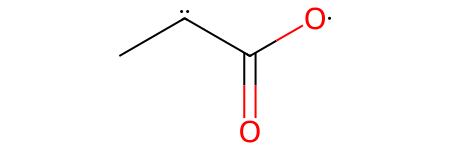

In [ ]:
def smiles_to_mol(smiles_string):
    try:
        mol = Chem.MolFromSmiles(smiles_string)
        if mol is not None:
            print(f"Displaying molecule for SMILES: {smiles_string}")
            display(mol)
        else:
            print(f"Could not parse SMILES: {smiles_string}")
    except Exception as e:
        print(f"Error processing SMILES '{smiles_string}': {e}")
smiles_to_mol('C[C]C(=O)[O]')